In [8]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# sys.path.insert(0, str(Path.cwd().parent))
load_dotenv()

from agents.state   import BabyOSState, make_initial_state, week_to_phase
from agents.supervisor import supervisor_node
from agents.agentsv2  import (
    medical_agent, tracker_agent, emotional_agent,
    parent_agent, hebamme_agent, germany_agent,
)
from agents.vision  import vision_node



In [9]:
DEBUG_MODE = os.getenv("DEBUG_MODE")

_retriever = None

def _get_retriever():
    global _retriever
    if _retriever is None:
        from rag.rag_system import BabyOSRetriever
        _retriever = BabyOSRetriever(k=4, use_multi_query=True)
    return _retriever

In [10]:
def input_node(state: BabyOSState) -> dict:
    messages = state.get("messages", [])
    profile  = state.get("user_profile", {})

    current_query = ""
    for msg in reversed(messages):
        if hasattr(msg, "type") and msg.type == "human":
            current_query = msg.content
            break

    week = profile.get("current_week", 20)
    pp   = profile.get("postpartum_weeks", 0)
    phase = week_to_phase(week, pp)

    return {
        "current_query":      current_query,
        "current_week":       week,
        "postpartum_weeks":   pp,
        "current_phase":      phase,
        "user_role":          profile.get("role", "mom"),
        "agent_response":     "",
        "agent_name":         "",
        "danger_flag":        False,
        "danger_reason":      None,
        "retrieved_context":  "",
        "retrieved_sources":  [],
    }

In [11]:
def retriever_node(state: BabyOSState) -> dict:
    query = state["current_query"]
    week  = state["current_week"]
    pp    = state["postpartum_weeks"]
    role  = state["user_role"]

    if not query.strip():
        return {"retrieved_context": "", "retrieved_sources": []}

    # Pass postpartum context to retriever so it can bias towards relevant docs
    effective_query = query
    if pp > 0:
        months = round(pp / 4.33, 1)
        effective_query = f"[postpartum {months} months] {query}"

    agent_name = state.get("run_metadata", {}).get("routed_to", "default")
    phase      = state.get("current_phase", "")

    try:
        retriever = _get_retriever()
        
        if(DEBUG_MODE):
            docs      = retriever.debug_retrieve(
            effective_query,
            week=week if pp == 0 else None,
            role=role,
            phase=phase,
            agent_name=agent_name,
        )
        else:
            docs      = retriever.retrieve(
            effective_query,
            week=week if pp == 0 else None,
            role=role,
            phase=phase,
            agent_name=agent_name,
        )
        context   = retriever.format_context(docs)
        sources   = list({d.metadata.get("source_file", "?") for d in docs})
    except Exception as e:
        print(f"[retriever_node] Warning: {e}")
        context = "Knowledge base temporarily unavailable."
        sources = []

    return {"retrieved_context": context, "retrieved_sources": sources}


In [12]:
def output_node(state: BabyOSState) -> dict:
    response    = state.get("agent_response", "")
    agent_name  = state.get("agent_name", "BabyOS")
    danger_flag = state.get("danger_flag", False)

    if danger_flag and "112" not in response:
        banner = (
            "🚨 **Seek medical attention immediately.**\n"
            "Call **112** (emergency) · **116 117** (urgent) · "
            "or go to the **Kreißsaal** / **Notaufnahme**.\n\n"
        )
        response = banner + response

    response = response.rstrip()
    response += f"\n\n<small>*{agent_name} · Born Together 🌱*</small>"

    return {
        "agent_response": response,
        "run_metadata": {
            **state.get("run_metadata", {}),
            "agent_name":  agent_name,
            "danger_flag": danger_flag,
            "phase":       state.get("current_phase"),
            "role":        state.get("user_role"),
        },
    }

In [13]:
def route_to_agent(state: BabyOSState) -> str:
    return state.get("next_agent", "medical_agent")

In [14]:
def build_graph():
    builder = StateGraph(BabyOSState)

    builder.add_node("input_node",      input_node)
    builder.add_node("vision_node",     vision_node)
    builder.add_node("retriever_node",  retriever_node)
    builder.add_node("supervisor_node", supervisor_node)
    builder.add_node("medical_agent",   medical_agent)
    builder.add_node("tracker_agent",   tracker_agent)
    builder.add_node("emotional_agent", emotional_agent)
    builder.add_node("parent_agent",    parent_agent)
    builder.add_node("hebamme_agent",   hebamme_agent)
    builder.add_node("germany_agent",   germany_agent)
    builder.add_node("output_node",     output_node)

    builder.add_edge(START,            "input_node")
    builder.add_edge("input_node",     "vision_node")    # vision runs even if no image (no-op)
    builder.add_edge("vision_node",    "retriever_node")
    builder.add_edge("retriever_node", "supervisor_node")

    builder.add_conditional_edges(
        "supervisor_node",
        route_to_agent,
        {
            "medical_agent":   "medical_agent",
            "tracker_agent":   "tracker_agent",
            "emotional_agent": "emotional_agent",
            "parent_agent":    "parent_agent",
            "hebamme_agent":   "hebamme_agent",
            "germany_agent":   "germany_agent",
            "FINISH":          "output_node",
        }
    )

    for agent in ["medical_agent", "tracker_agent", "emotional_agent",
                  "parent_agent", "hebamme_agent", "germany_agent"]:
        builder.add_edge(agent, "output_node")

    builder.add_edge("output_node", END)

    memory   = MemorySaver()
    return builder.compile(checkpointer=memory)



In [16]:
_graph = None

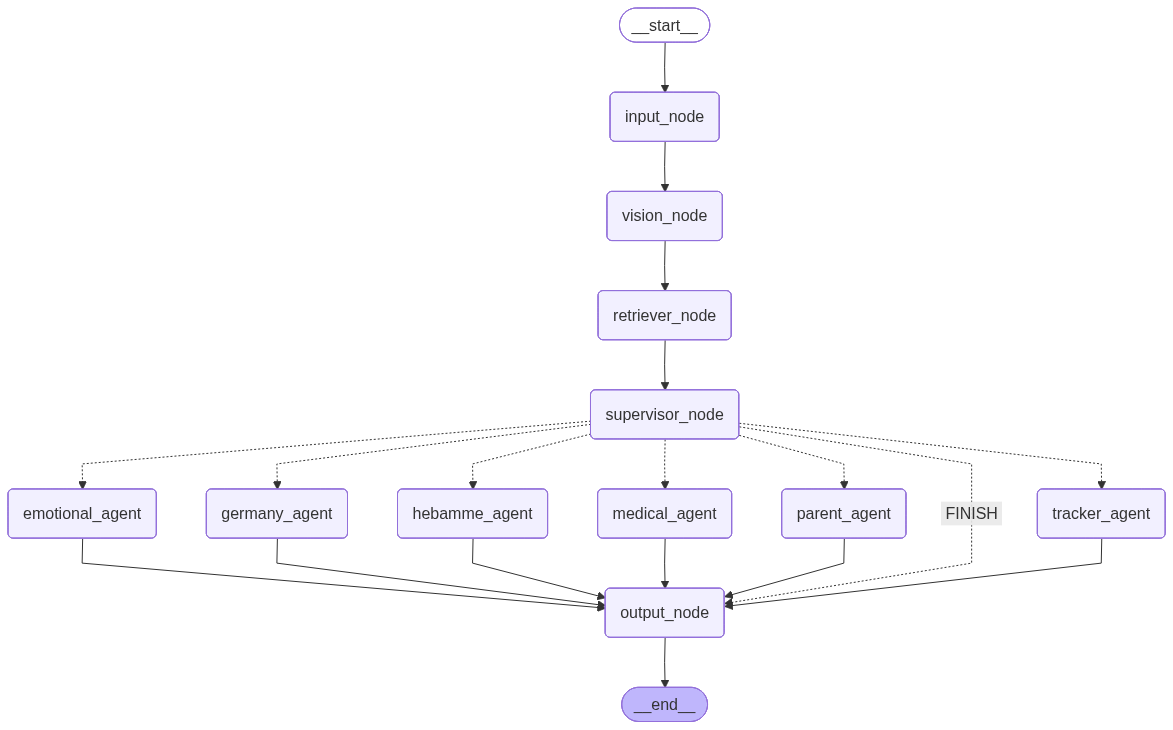

In [17]:
def get_graph():
    global _graph
    if _graph is None:
        _graph = build_graph()
    return _graph

from IPython.display import Image, display


graph=get_graph()
display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
def chat(message: str, state: BabyOSState, thread_id: str = "default",
         image_b64: str = None, image_type: str = None) -> tuple[str, BabyOSState]:
    """
    Main entry point.
    
    Args:
        message:    User text message
        state:      Current BabyOSState
        thread_id:  Unique session ID (use st.session_state user id)
        image_b64:  Optional base64 image string
        image_type: Optional hint: "mutterpass"|"ultrasound"|"blood_report"|"urine_report"|"ctg"|"other"
    """
    graph  = get_graph()
    config = {"configurable": {"thread_id": thread_id}}

    input_state = {
        **state,
        "messages": state.get("messages", []) + [HumanMessage(content=message)],
    }

    if image_b64:
        input_state["uploaded_image_b64"]  = image_b64
        input_state["uploaded_image_type"] = image_type or "other"

    result = graph.invoke(input_state, config=config)
    return result["agent_response"], result


In [19]:
user_profile={
    "current_week":20,
    "postpartum_weeks":0,
    "role":"mom",
    }

init_state = make_initial_state(user_profile)

In [20]:

response = chat(
    message="Is it normal to feel short of breath during pregnancy",
    state=init_state
)

print(response)

[RAG] Loaded: babyos_development, babyos_medical, babyos_germany, babyos_dad, babyos_faqs, babyos_web, babyos_books

  QUERY : Is it normal to feel short of breath during pregnancy
  WEEK  : 20   ROLE: mom   PHASE: T2
  AGENT : default
Routing for query:  Is it normal to feel short of breath during pregnancy

  Router selected: ['babyos_medical', 'babyos_faqs']
Detecting Book Topic for query:  Is it normal to feel short of breath during pregnancy
  Book topic tag:  nutrition
Routing for query:  Is it normal to feel short of breath during pregnancy
Retrieving Book Topic for query:  3 Is it normal to feel short of breath during pregnancy
Detecting Book Topic for query:  Is it normal to feel short of breath during pregnancy

  Total chunks retrieved: 13

  [babyos_medical] — 5 chunk(s)
    medical_reference.md: | Headaches | Common in first and second trimester | Severe or persistent headache in third trimeste...
    medical_reference.md: | Symptom | Normal | Seek Help If... | |---------|

In [36]:
# debug#1

QSTN_TEST=[
    "Is it normal to feel short of breath during pregnancy",
    "Is itching with discharge normal or dangerous",
    "Why does vaginal discharge increase in pregnancy",
    "How much coffee is allowed in pregnancy per day",
    "Is it safe to fly during pregnancy",
    "Why do my feet and ankles swell in pregnancy",
    "Why do i get blurry vision or nausea with low bp",
    "Why do i have moodswings",
    "Is L4,l5 backpain is normal in pregnancy",
    "Is physiotherapy safe during pregnancy",
    "Can baby position affect nerve pain",
    "Can i take painkillers during prgnancy",
    "Could low oxygen levels permanently affect the baby",
    "Could spinal problems worsen during pregnancy",
    "What causes premature birth",
    "Could low Bp affect the baby's growth",
    "Is Sex safe during Pregnancy",
    "How can i support my partner",
    "what kind of foods can i eat",
    "What should dads prepare during week 30?"
]

for q in QSTN_TEST:
    response = chat(
    message=q,
    state=init_state
    )   
    print(response)
    print("------------------------------------------------------------------------")


  QUERY : Is it normal to feel short of breath during pregnancy
  WEEK  : 20   ROLE: mom   PHASE: T2
  AGENT : default

  Router selected: ['babyos_medical', 'babyos_faqs']
  Book topic tag:  nutrition

  Total chunks retrieved: 13

  [babyos_medical] — 5 chunk(s)
    medical_reference.md: | Headaches | Common in first and second trimester | Severe or persistent headache in third trimeste...
    medical_reference.md: | Symptom | Normal | Seek Help If... | |---------|--------|----------------| | Nausea and vomiting |...
    medical_reference.md: ### Third Trimester (Weeks 28–40): - Reduced or absent fetal movement (after 28 weeks, should feel 1...
    medical_reference.md: ### First Trimester (Weeks 1–12): - One-sided abdominal pain with or without bleeding (possible ecto...
    medical_reference.md: ---  ## Preeclampsia — What It Means  Preeclampsia is a serious condition affecting blood pressure a...

  [babyos_faqs] — 5 chunk(s)
    pregnancy_faqs.md: **Q: Can I exercise during preg